Loaded /content/Cleaned_Learners_Dataset.csv (shape=(500, 15))
Loaded /content/Cleaned_Job_Skills_Dataset.csv (shape=(223, 14))
Loaded /content/Expanded_Hybrid_Courses__sample_.csv (shape=(28, 4))
Using provided data files.
Skill order used: ['python', 'sql', 'machine learning', 'ml', 'cloud', 'cybersecurity', 'data analysis', 'java', 'c#', 'r', 'statistics', 'communication', 'teamwork']
Skills detected: 13 ['python', 'sql', 'machine learning', 'ml', 'cloud', 'cybersecurity', 'data analysis', 'java', 'c#', 'r', 'statistics', 'communication', 'teamwork']
Courses (actions): 28 Learners shape: (500, 13)
Saved Q-table at episode 200 to results/q_table_ep200.json
Saved Q-table at episode 400 to results/q_table_ep400.json
Saved Q-table at episode 600 to results/q_table_ep600.json
Saved Q-table at episode 800 to results/q_table_ep800.json
Saved training summary.
Saved results/reward_history.png


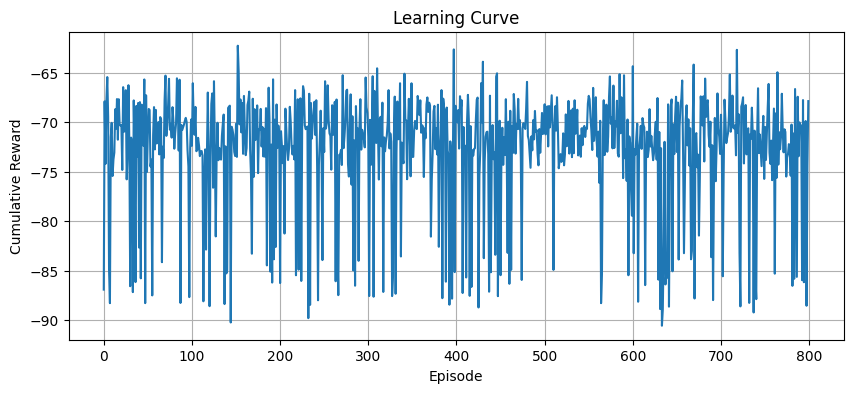

Saved results/gap_history.png


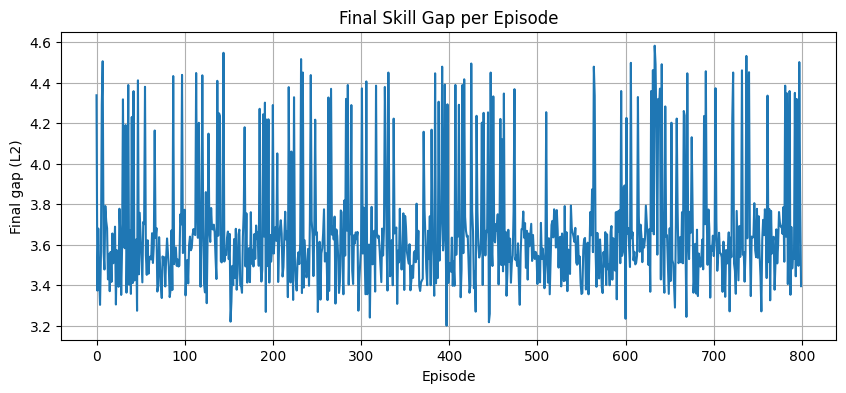

Saved final Q-table to results/q_table_final.json
Demo plan indices: [6, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Course names: ['Applied Machine Learning Projects', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)']


In [ ]:
"""
training code
"""

import os, json, random
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "data"
RESULTS_DIR = "results"
LEARNERS_FILE = "/content/Cleaned_Learners_Dataset.csv"
JOB_SKILLS_FILE = "/content/Cleaned_Job_Skills_Dataset.csv"
COURSES_FILE = "/content/Expanded_Hybrid_Courses__sample_.csv"

NUM_EPISODES = 800
MAX_STEPS_PER_EPISODE = 20
DISCRETIZE_BINS = 10
ALPHA = 0.2
GAMMA = 0.95
EPS_START = 0.3
EPS_END = 0.01
EPS_DECAY_EPISODES = 600
SAVE_EVERY = 200
DONE_TOL = 0.05

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DEFAULT_SKILL_ORDER = [
    "python","sql","machine learning","ml","cloud","cybersecurity",
    "data analysis","java","c#","r","statistics","communication","teamwork"
]

def try_load_csv(path):
    try:
        df = pd.read_csv(path)
        print(f"Loaded {path} (shape={df.shape})")
        return df
    except Exception as e:
        print(f"Could not load {path}: {e}")
        return None

def parse_course_row(skill_index_field, improvement_field):
    si = str(skill_index_field).strip()
    imp = str(improvement_field).strip()
    si_list = [s.strip() for s in si.split(",") if s.strip()!='']
    imp_list = [s.strip() for s in imp.split(",") if s.strip()!='']
    si_idx = [int(x) for x in si_list]
    imp_vals = [float(x) for x in imp_list]
    if len(si_idx) != len(imp_vals):
        raise ValueError("skill_index and improvement lengths mismatch")
    return si_idx, imp_vals

def load_or_create_all():
    learners_path = os.path.join(DATA_DIR, LEARNERS_FILE)
    jobs_path = os.path.join(DATA_DIR, JOB_SKILLS_FILE)
    courses_path = os.path.join(DATA_DIR, COURSES_FILE)

    learners_df = try_load_csv(learners_path)
    jobs_df = try_load_csv(jobs_path)
    courses_df = try_load_csv(courses_path)

    if learners_df is None or jobs_df is None or courses_df is None:
        print("One or more files missing — building small synthetic dataset.")
        num_skills = len(DEFAULT_SKILL_ORDER)
        learners = []
        for i in range(10):
            skills = np.round(np.random.uniform(0.1, 0.6, size=num_skills), 3)
            row = {"learner_id": i}
            for j, s in enumerate(DEFAULT_SKILL_ORDER):
                row[s] = float(skills[j])
            row["TargetRole"] = "TargetRole"
            learners.append(row)
        learners_df = pd.DataFrame(learners)
        job_row = {"role_name": "TargetRole"}
        for s in DEFAULT_SKILL_ORDER:
            job_row[s] = 0.85
        jobs_df = pd.DataFrame([job_row])
        courses = [
            (1, "Intro to Python", "0", "0.30"),
            (2, "SQL for Data Science", "1", "0.25"),
            (3, "Machine Learning Basics", "2", "0.40"),
            (4, "Cloud Fundamentals", "4", "0.35"),
            (5, "Cybersecurity Essentials", "5", "0.30"),
            (6, "Data Analysis Projects", "6", "0.35"),
            (7, "Communication Skills Workshop", "11", "0.25"),
            (8, "Teamwork Workshop", "12", "0.20"),
        ]
        courses_df = pd.DataFrame(courses, columns=["course_id","course_name","skill_index","improvement"])
    else:
        print("Using provided data files.")

    # canonical skill order
    skill_order = None
    if jobs_df is not None:
        cols = [c for c in jobs_df.columns if c != "role_name"]
        if len(cols) > 0:
            skill_order = cols
    if skill_order is None:
        candidate = [c for c in learners_df.columns if c not in ("learner_id","name","TargetRole")]
        if len(candidate) > 0:
            skill_order = candidate
    if skill_order is None:
        skill_order = DEFAULT_SKILL_ORDER
    skill_order = list(skill_order)
    print("Skill order used:", skill_order)

    # ensure skill columns exist
    for s in skill_order:
        if s not in learners_df.columns:
            learners_df[s] = 0.0
        if s not in jobs_df.columns:
            jobs_df[s] = 0.0

    # parse course rows and extend skill_order if needed
    num_skills = len(skill_order)
    course_records = []
    for _, r in courses_df.iterrows():
        cid = r.get("course_id")
        cname = r.get("course_name")
        si, imp = parse_course_row(r["skill_index"], r["improvement"])
        if max(si) >= num_skills:
            for new_idx in range(num_skills, max(si)+1):
                placeholder = f"_skill_{new_idx}"
                skill_order.append(placeholder)
                learners_df[placeholder] = 0.0
                jobs_df[placeholder] = 0.0
            num_skills = len(skill_order)
        course_records.append((int(cid), str(cname), ",".join(map(str, si)), ",".join(map(str, imp))))

    courses_clean_df = pd.DataFrame(course_records, columns=["course_id","course_name","skill_index","improvement"])

    learners_matrix = learners_df[skill_order].values.astype(float)
    target_row = jobs_df.iloc[0]
    target_vector = np.array([float(target_row[s]) for s in skill_order])
    course_effects = []
    for _, r in courses_clean_df.iterrows():
        si, imp = parse_course_row(r["skill_index"], r["improvement"])
        course_effects.append((si, imp))

    return skill_order, learners_matrix, course_effects, target_vector, learners_df, jobs_df, courses_clean_df

class SkillGapEnv:
    def __init__(self, initial_skills, target_skills, course_effects, max_steps=20, done_tol=0.05):
        self.initial = np.array(initial_skills, dtype=float)
        self.state = self.initial.copy()
        self.target = np.array(target_skills, dtype=float)
        self.course_effects = course_effects
        self.max_steps = max_steps
        self.step_count = 0
        self.done_tol = done_tol
        self.action_space = len(course_effects)
    def reset(self, initial_skills=None):
        if initial_skills is not None:
            self.initial = np.array(initial_skills, dtype=float)
        self.state = self.initial.copy()
        self.step_count = 0
        return self.state.copy()
    def step(self, action):
        si_list, imp_list = self.course_effects[action]
        for si, imp in zip(si_list, imp_list):
            self.state[si] = min(1.0, self.state[si] + imp)
        gap = np.linalg.norm(self.target - self.state)
        reward = -gap
        self.step_count += 1
        done = (gap <= self.done_tol) or (self.step_count >= self.max_steps)
        return self.state.copy(), float(reward), done, {"gap": float(gap)}

def discretize_state(state, bins):
    inds = np.floor(state * bins).astype(int)
    inds = np.clip(inds, 0, bins-1)
    return tuple(inds.tolist())

class TabularQLearner:
    def __init__(self, action_space, state_bins, alpha=0.2, gamma=0.95, epsilon=0.2):
        self.action_space = action_space
        self.state_bins = state_bins
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q = defaultdict(lambda: np.zeros(self.action_space))
    def choose(self, state_key):
        if random.random() < self.epsilon:
            return random.randrange(self.action_space)
        return int(np.argmax(self.q[state_key]))
    def update(self, state_key, action, reward, next_state_key):
        best_next = np.max(self.q[next_state_key])
        td = reward + self.gamma * best_next - self.q[state_key][action]
        self.q[state_key][action] += self.alpha * td

def train_q_learning(skill_names, learners, course_effects, target_skills):
    bins = DISCRETIZE_BINS
    qlearner = TabularQLearner(action_space=len(course_effects), state_bins=bins,
                               alpha=ALPHA, gamma=GAMMA, epsilon=EPS_START)
    reward_history, gap_history = [], []
    for ep in range(NUM_EPISODES):
        start_idx = np.random.randint(0, learners.shape[0])
        env = SkillGapEnv(initial_skills=learners[start_idx], target_skills=target_skills,
                          course_effects=course_effects, max_steps=MAX_STEPS_PER_EPISODE, done_tol=DONE_TOL)
        state = env.reset()
        state_key = discretize_state(state, bins)
        total_reward = 0.0
        eps = max(EPS_END, EPS_START - (EPS_START - EPS_END) * (ep / EPS_DECAY_EPISODES))
        qlearner.epsilon = eps
        for _ in range(MAX_STEPS_PER_EPISODE):
            action = qlearner.choose(state_key)
            next_state, reward, done, info = env.step(action)
            next_state_key = discretize_state(next_state, bins)
            qlearner.update(state_key, action, reward, next_state_key)
            state_key = next_state_key
            total_reward += reward
            if done:
                break
        reward_history.append(total_reward)
        gap_history.append(info["gap"])
        if (ep + 1) % SAVE_EVERY == 0:
            qpath = os.path.join(RESULTS_DIR, f"q_table_ep{ep+1}.json")
            serializable_q = {str(k): v.tolist() for k, v in qlearner.q.items()}
            with open(qpath, "w") as f:
                json.dump(serializable_q, f)
            print(f"Saved Q-table at episode {ep+1} to {qpath}")
    return qlearner, reward_history, gap_history

def plot_results(reward_history, gap_history):
    plt.figure(figsize=(10,4)); plt.plot(reward_history); plt.xlabel("Episode"); plt.ylabel("Cumulative Reward")
    plt.title("Learning Curve"); plt.grid(True)
    p = os.path.join(RESULTS_DIR, "reward_history.png"); plt.savefig(p); print("Saved", p); plt.show()
    plt.figure(figsize=(10,4)); plt.plot(gap_history); plt.xlabel("Episode"); plt.ylabel("Final gap (L2)")
    plt.title("Final Skill Gap per Episode"); plt.grid(True)
    p2 = os.path.join(RESULTS_DIR, "gap_history.png"); plt.savefig(p2); print("Saved", p2); plt.show()

if __name__ == "__main__":
    skill_names, learners, course_effects, target_skills, learners_df, jobs_df, courses_df = load_or_create_all()
    print("Skills detected:", len(skill_names), skill_names[:20])
    print("Courses (actions):", len(course_effects), "Learners shape:", learners.shape)
    qlearner, reward_hist, gap_hist = train_q_learning(skill_names, learners, course_effects, target_skills)
    summary = pd.DataFrame({"episode": list(range(1, len(reward_hist)+1)), "reward": reward_hist, "final_gap": gap_hist})
    summary.to_csv(os.path.join(RESULTS_DIR, "training_summary.csv"), index=False)
    print("Saved training summary.")
    plot_results(reward_hist, gap_hist)
    # Save final Q-table
    qpath = os.path.join(RESULTS_DIR, f"q_table_final.json")
    with open(qpath, "w") as f:
        json.dump({str(k): v.tolist() for k, v in qlearner.q.items()}, f)
    print("Saved final Q-table to", qpath)
    # Demo
    env = SkillGapEnv(initial_skills=learners[0], target_skills=target_skills, course_effects=course_effects, max_steps=10)
    state = env.reset(); state_key = discretize_state(state, DISCRETIZE_BINS)
    plan = []
    for _ in range(10):
        a = int(np.argmax(qlearner.q[state_key])); plan.append(a)
        s, r, done, info = env.step(a); state_key = discretize_state(s, DISCRETIZE_BINS)
        if done: break
    print("Demo plan indices:", plan)
    try:
        names = list(courses_df["course_name"]); print("Course names:", [names[i] if i < len(names) else f"Course_{i}" for i in plan])
    except Exception:
        pass


In [ ]:
"""
testing code
"""

import os
import json
import argparse
import numpy as np
import pandas as pd

DATA_DIR = "data"
RESULTS_DIR = "results"
LEARNERS_FILE = "/content/Cleaned_Learners_Dataset.csv"
JOB_SKILLS_FILE = "/content/Cleaned_Job_Skills_Dataset.csv"
COURSES_FILE = "/content/Expanded_Hybrid_Courses__sample_.csv"
QTABLE_FILE_CANDIDATES = ["q_table_final.json", "q_table_ep800.json", "q_table_ep600.json"]

DISCRETIZE_BINS = 10
MAX_STEPS = 10
DEFAULT_SKILL_ORDER = [
    "python","sql","machine learning","ml","cloud","cybersecurity",
    "data analysis","java","c#","r","statistics","communication","teamwork"
]

def load_q_table(path):
    with open(path, "r") as f:
        raw = json.load(f)
    q = {}
    for k, v in raw.items():
        try:
            key = eval(k)
            if isinstance(key, int):
                key = (key,)
        except Exception:
            # fallback parsing like "(0,1,2)"
            try:
                key = tuple(int(x) for x in k.strip("()[] ").split(",") if x.strip()!='')
            except Exception:
                key = (k,)
        q[key] = np.array(v)
    return q

def discretize_state(state, bins):
    inds = np.floor(state * bins).astype(int)
    inds = np.clip(inds, 0, bins-1)
    return tuple(inds.tolist())

def parse_course_row(skill_index_field, improvement_field):
    si = str(skill_index_field).strip()
    imp = str(improvement_field).strip()
    si_list = [s.strip() for s in si.split(",") if s.strip()!='']
    imp_list = [s.strip() for s in imp.split(",") if s.strip()!='']
    return [int(x) for x in si_list], [float(x) for x in imp_list]

def infer(learner_vec=None, learner_index=None, qpath=None):
    # load CSVs if present
    learners_df = pd.read_csv(os.path.join(DATA_DIR, LEARNERS_FILE)) if os.path.exists(os.path.join(DATA_DIR, LEARNERS_FILE)) else None
    jobs_df = pd.read_csv(os.path.join(DATA_DIR, JOB_SKILLS_FILE)) if os.path.exists(os.path.join(DATA_DIR, JOB_SKILLS_FILE)) else None
    courses_df = pd.read_csv(os.path.join(DATA_DIR, COURSES_FILE)) if os.path.exists(os.path.join(DATA_DIR, COURSES_FILE)) else None

    # skill order detection
    skill_order = None
    if jobs_df is not None:
        cols = [c for c in jobs_df.columns if c != "role_name"]
        if cols:
            skill_order = cols
    if skill_order is None and learners_df is not None:
        candidate = [c for c in learners_df.columns if c not in ("learner_id","name","TargetRole")]
        if candidate:
            skill_order = candidate
    if skill_order is None:
        skill_order = DEFAULT_SKILL_ORDER
    skill_order = list(skill_order)

    if courses_df is None:
        raise FileNotFoundError("courses file not found. Place courses_expanded_hybrid.csv in data/")

    # parse course effects
    course_effects = []
    for _, r in courses_df.iterrows():
        si, imp = parse_course_row(r["skill_index"], r["improvement"])
        course_effects.append((si, imp))

    # find q-table
    if qpath is None:
        for cand in QTABLE_FILE_CANDIDATES:
            p = os.path.join(RESULTS_DIR, cand)
            if os.path.exists(p):
                qpath = p
                break
    if qpath is None:
        raise FileNotFoundError("No q-table found in results/. Run training first or provide --qpath")
    qdict = load_q_table(qpath)

    # prepare initial state
    if learner_vec is not None:
        state = np.array(learner_vec, dtype=float)
        if len(state) < len(skill_order):
            state = np.concatenate([state, np.zeros(len(skill_order) - len(state))])
    else:
        if learners_df is None:
            raise FileNotFoundError("No learners CSV found and no vector provided.")
        if learner_index is None:
            learner_index = 0
        state = learners_df[skill_order].iloc[learner_index].values.astype(float)

    # greedy rollout
    plan_indices = []
    plan_names = []
    for step in range(MAX_STEPS):
        state_key = discretize_state(state, DISCRETIZE_BINS)
        qvals = qdict.get(state_key, np.zeros(len(course_effects)))
        action = int(np.argmax(qvals))
        plan_indices.append(action)
        si, imp = course_effects[action]
        for s_i, dv in zip(si, imp):
            if s_i < len(state):
                state[s_i] = min(1.0, state[s_i] + dv)
        # get name
        try:
            cname = courses_df.iloc[action]["course_name"]
        except Exception:
            cname = f"Course_{action}"
        plan_names.append(cname)

    # compute gap vs first job target if present
    if jobs_df is not None:
        target = jobs_df.iloc[0][skill_order].values.astype(float)
        final_gap = np.linalg.norm(target - state)
        initial_gap = np.linalg.norm(target - (learners_df[skill_order].iloc[learner_index].values.astype(float) if learners_df is not None and learner_vec is None else (np.array(learner_vec) if learner_vec is not None else None)))
    else:
        final_gap = None; initial_gap = None

    return {
        "initial_vector": (None if learner_vec is not None else learners_df[skill_order].iloc[learner_index].values.astype(float)) if learners_df is not None else learner_vec,
        "plan_indices": plan_indices,
        "plan_names": plan_names,
        "initial_gap": float(initial_gap) if initial_gap is not None else None,
        "final_gap": float(final_gap) if final_gap is not None else None
    }

def main(argv=None):
    parser = argparse.ArgumentParser()
    parser.add_argument("--learner-index", type=int, default=None, help="index into learners CSV to use")
    parser.add_argument("--vector", type=str, default=None, help="comma-separated custom skill vector (0-1)")
    parser.add_argument("--qpath", type=str, default=None, help="path to q-table json")
    # Use parse_known_args to ignore unknown args injected by Jupyter/Colab kernels
    if argv is None:
        args, unknown = parser.parse_known_args()
    else:
        args = parser.parse_args(argv)

    learner_index = args.learner_index
    learner_vec = None
    if args.vector is not None:
        learner_vec = [float(x) for x in args.vector.split(",")]
    res = infer(learner_vec=learner_vec, learner_index=learner_index, qpath=args.qpath)

    print("Recommended course sequence (indices):", res["plan_indices"])
    print("Recommended course sequence (names):", res["plan_names"])
    if res["initial_gap"] is not None:
        print(f"Initial gap: {res['initial_gap']:.4f}, Final gap: {res['final_gap']:.4f}, Reduction: {res['initial_gap'] - res['final_gap']:.4f}")

if __name__ == "__main__":
    # If you run this inside a notebook and want to provide specific args, you can:
    #   main(["--learner-index", "2"])
    # or run as normal: python inference_skill_gap_rl_safe.py --learner-index 0
    main()


Recommended course sequence (indices): [6, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Recommended course sequence (names): ['Applied Machine Learning Projects', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)']
Initial gap: 3.4077, Final gap: 3.4169, Reduction: -0.0092


In [ ]:
"testing code"

import os, json
from collections import defaultdict
import numpy as np
import pandas as pd

DATA_DIR = "data"
RESULTS_DIR = "results"
LEARNERS_FILE = "/content/Cleaned_Learners_Dataset.csv"
JOB_SKILLS_FILE = "/content/Cleaned_Job_Skills_Dataset.csv"
COURSES_FILE = "/content/Expanded_Hybrid_Courses__sample_.csv"
QTABLE_FILE_CANDIDATES = ["q_table_final.json", "q_table_ep800.json", "q_table_ep600.json"]

DISCRETIZE_BINS = 10
MAX_STEPS = 10
DEFAULT_SKILL_ORDER = [
    "python","sql","machine learning","ml","cloud","cybersecurity",
    "data analysis","java","c#","r","statistics","communication","teamwork"
]

# --- User-definable parameters ---
# Set to an integer to use a specific learner from the CSV (e.g., 0 for the first learner).
# Set to None to use a custom_skill_vector.
learner_index = 0  # Example: use the first learner in the dataset

# Provide a comma-separated string of skill values (0-1) for a custom learner profile.
# This will be used if learner_index is None.
custom_skill_vector = None # Example: "0.5,0.2,0.8,0.1"

# Path to the Q-table JSON file. Leave None to automatically select the latest saved Q-table.
qpath_override = None # Example: "results/q_table_final.json"
# ----------------------------------

def load_q_table(path):
    with open(path, "r") as f:
        raw = json.load(f)
    # convert keys back to tuples
    q = {}
    for k, v in raw.items():
        # keys may be like "(0,1,2)" or "('0','1')"
        try:
            key = eval(k)
            if isinstance(key, int): key = (key,)
        except Exception:
            # fallback: attempt to parse string representation of tuple
            key = tuple(int(x) for x in k.strip("()[] ").split(",") if x.strip()!='')
        q[key] = np.array(v)
    return q

def discretize_state(state, bins):
    inds = np.floor(state * bins).astype(int)
    inds = np.clip(inds, 0, bins-1)
    return tuple(inds.tolist())

def parse_course_row(skill_index_field, improvement_field):
    si = str(skill_index_field).strip()
    imp = str(improvement_field).strip()
    si_list = [s.strip() for s in si.split(",") if s.strip()!='']
    imp_list = [s.strip() for s in imp.split(",") if s.strip()!='']
    return [int(x) for x in si_list], [float(x) for x in imp_list]

class SkillGapEnv:
    def __init__(self, initial_skills, target_skills, course_effects, max_steps=20, done_tol=0.05):
        self.initial = np.array(initial_skills, dtype=float)
        self.state = self.initial.copy()
        self.target = np.array(target_skills, dtype=float)
        self.course_effects = course_effects
        self.max_steps = max_steps
        self.step_count = 0
        self.done_tol = done_tol
        self.action_space = len(course_effects)
    def reset(self, initial_skills=None):
        if initial_skills is not None:
            self.initial = np.array(initial_skills, dtype=float)
        self.state = self.initial.copy()
        self.step_count = 0
        return self.state.copy()
    def step(self, action):
        si_list, imp_list = self.course_effects[action]
        for si, imp in zip(si_list, imp_list):
            self.state[si] = min(1.0, self.state[si] + imp)
        gap = np.linalg.norm(self.target - self.state)
        reward = -gap
        self.step_count += 1
        done = (gap <= self.done_tol) or (self.step_count >= self.max_steps)
        return self.state.copy(), float(reward), done, {"gap": float(gap)}

def main():
    # load data
    learners_path = os.path.join(DATA_DIR, LEARNERS_FILE)
    jobs_path = os.path.join(DATA_DIR, JOB_SKILLS_FILE)
    courses_path = os.path.join(DATA_DIR, COURSES_FILE)

    learners_df = None
    jobs_df = None
    courses_df = None
    if os.path.exists(learners_path): learners_df = pd.read_csv(learners_path)
    if os.path.exists(jobs_path): jobs_df = pd.read_csv(jobs_path)
    if os.path.exists(courses_path): courses_df = pd.read_csv(courses_path)

    # choose skill order
    skill_order = None
    if jobs_df is not None:
        cols = [c for c in jobs_df.columns if c != "role_name"]
        if len(cols) > 0: skill_order = cols
    if skill_order is None and learners_df is not None:
        candidate = [c for c in learners_df.columns if c not in ("learner_id","name","TargetRole")]
        if len(candidate) > 0: skill_order = candidate
    if skill_order is None:
        skill_order = DEFAULT_SKILL_ORDER
    skill_order = list(skill_order)

    # parse courses
    if courses_df is None:
        raise FileNotFoundError("courses file not found. Place courses_expanded_hybrid.csv in data/ or run training script first.")
    course_effects = []
    for _, r in courses_df.iterrows():
        si, imp = parse_course_row(r["skill_index"], r["improvement"])
        course_effects.append((si, imp))

    # choose Q-table
    qpath = qpath_override
    if qpath is None:
        for cand in QTABLE_FILE_CANDIDATES:
            p = os.path.join(RESULTS_DIR, cand)
            if os.path.exists(p):
                qpath = p; break
    if qpath is None:
        raise FileNotFoundError("No q-table found in results/. Run training first or provide qpath_override")
    qdict = load_q_table(qpath)

    # get initial skill vector
    if custom_skill_vector is not None:
        vec = np.array([float(x) for x in custom_skill_vector.split(",")], dtype=float)
        if len(vec) < len(skill_order):
            vec = np.concatenate([vec, np.zeros(len(skill_order)-len(vec))])
        elif len(vec) > len(skill_order):
            vec = vec[:len(skill_order)] # truncate if too long
    else:
        if learners_df is None:
            raise FileNotFoundError("No learners CSV found and no custom_skill_vector provided.")
        if learner_index is None:
            idx = 0 # Default to first learner if no index or vector provided
        else:
            idx = learner_index
        vec = learners_df[skill_order].iloc[idx].values.astype(float)

    # inference: greedy rollout
    state = vec.copy()
    plan_indices = []
    plan_names = []
    for step in range(MAX_STEPS):
        state_key = discretize_state(state, DISCRETIZE_BINS)
        # if exact state_key not in qdict, use nearest (fallback: zeros)
        if state_key not in qdict:
            # fallback: choose random action (or argmax over zeros)
            qvals = np.zeros(len(course_effects))
        else:
            qvals = qdict[state_key]
        action = int(np.argmax(qvals))
        plan_indices.append(action)
        # apply action
        si, imp = course_effects[action]
        for s_i, dv in zip(si, imp):
            if s_i < len(state):
                state[s_i] = min(1.0, state[s_i] + dv)
        # course name if available
        try:
            cname = courses_df.iloc[action]["course_name"]
        except Exception:
            cname = f"Course_{action}"
        plan_names.append(cname)

    # final gap vs first job_role target (first in jobs_df)
    if jobs_df is not None:
        target = jobs_df.iloc[0][skill_order].values.astype(float)
        final_gap = np.linalg.norm(target - state)
        initial_gap = np.linalg.norm(target - vec)
    else:
        final_gap = None; initial_gap = None

    print("Initial skill vector (first 10):", vec[:10])
    print("Recommended course sequence (indices):", plan_indices)
    print("Recommended course sequence (names):", plan_names)
    if initial_gap is not None:
        print(f"Initial gap: {initial_gap:.4f}, Final gap after plan: {final_gap:.4f}, Reduction: {initial_gap - final_gap:.4f}")

if __name__ == "__main__":
    main()

Initial skill vector (first 10): [1. 1. 0. 0. 0. 1. 1. 0. 1. 1.]
Recommended course sequence (indices): [10, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Recommended course sequence (names): ['Probability & Statistics Refresher', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)', 'Python for Everybody (Beginner)']
Initial gap: 3.4077, Final gap after plan: 3.4148, Reduction: -0.0071


Loaded /content/Cleaned_Learners_Dataset.csv (shape=(500, 15))
Loaded /content/Cleaned_Job_Skills_Dataset.csv (shape=(223, 14))
Loaded /content/Expanded_Hybrid_Courses__sample_.csv (shape=(28, 4))
All three files found. Using them.
Canonical skill order used: ['python', 'sql', 'machine learning', 'ml', 'cloud', 'cybersecurity', 'data analysis', 'java', 'c#', 'r', 'statistics', 'communication', 'teamwork']
Detected 13 skills.
Sample skill names: ['python', 'sql', 'machine learning', 'ml', 'cloud', 'cybersecurity', 'data analysis', 'java', 'c#', 'r', 'statistics', 'communication', 'teamwork']
Number of courses (actions): 28
Learners shape: (500, 13)
Saved Q-table at episode 200 to results/q_table_ep200.json
Saved Q-table at episode 400 to results/q_table_ep400.json
Saved Q-table at episode 600 to results/q_table_ep600.json
Saved Q-table at episode 800 to results/q_table_ep800.json
Saved training summary to results/training_summary.csv
Saved results/reward_history.png


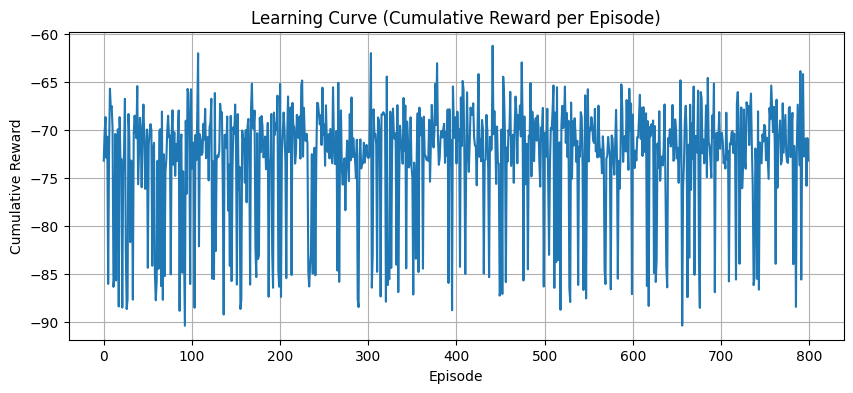

Saved results/gap_history.png


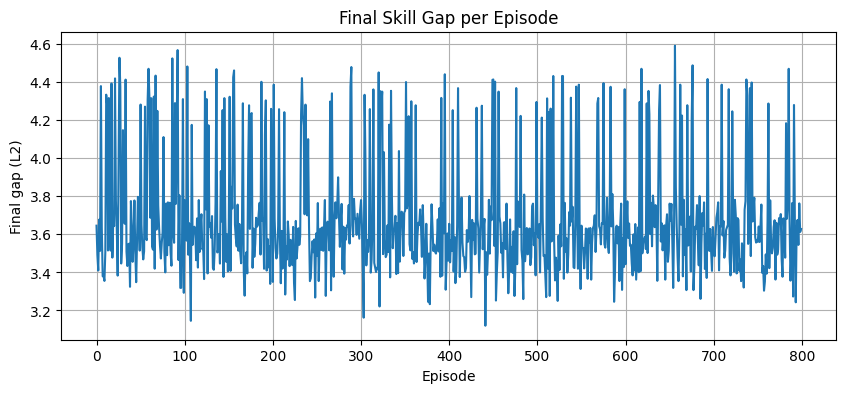


Demonstration run using greedy policy from learned Q-table
Recommended course sequence (indices): [14, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Course names: ['Azure Fundamentals', 'Advanced Python Programming', 'Advanced Python Programming', 'Advanced Python Programming', 'Advanced Python Programming', 'Advanced Python Programming', 'Advanced Python Programming', 'Advanced Python Programming', 'Advanced Python Programming', 'Advanced Python Programming']

Done. Check results/ for artifacts.


In [ ]:
"""
training and testing combined code
Skill-Gap-RL — updated loader + robust course parsing
Works with:
 - data/learners_clean.csv
 - data/job_skills_clean.csv
 - data/courses_expanded_hybrid.csv

If those files are missing it falls back to synthetic data (like before).
"""

import os
import json
import random
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: PyTorch for DQN if you want later (not required)
try:
    import torch, torch.nn as nn, torch.optim as optim
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

# -----------------------------
# CONFIG
# -----------------------------
DATA_DIR = "data"
RESULTS_DIR = "results"
LEARNERS_FILE = "/content/Cleaned_Learners_Dataset.csv"
JOB_SKILLS_FILE = "/content/Cleaned_Job_Skills_Dataset.csv"
COURSES_FILE = "/content/Expanded_Hybrid_Courses__sample_.csv"

NUM_EPISODES = 800
MAX_STEPS_PER_EPISODE = 20
DISCRETIZE_BINS = 10
ALPHA = 0.2
GAMMA = 0.95
EPS_START = 0.3
EPS_END = 0.01
EPS_DECAY_EPISODES = 600
SAVE_EVERY = 200
DONE_TOL = 0.05

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# A default skill list (kept in same order as earlier scripts)
DEFAULT_SKILL_ORDER = [
    "python","sql","machine learning","ml","cloud","cybersecurity",
    "data analysis","java","c#","r","statistics","communication","teamwork"
]

# -----------------------------
# Helpers
# -----------------------------
def try_load_csv(path):
    try:
        df = pd.read_csv(path)
        print(f"Loaded {path} (shape={df.shape})")
        return df
    except Exception as e:
        print(f"Could not load {path}: {e}")
        return None

def parse_course_row(skill_index_field, improvement_field):
    """
    Accepts skill_index_field (like "0" or "2,3") and improvement_field (like "0.3" or "0.2,0.15")
    Returns (list_of_int_indices, list_of_float_improvements)
    """
    si = str(skill_index_field).strip()
    imp = str(improvement_field).strip()
    si_list = [s.strip() for s in si.split(",") if s.strip()!='']
    imp_list = [s.strip() for s in imp.split(",") if s.strip()!='']
    try:
        si_idx = [int(x) for x in si_list]
    except ValueError:
        raise ValueError(f"Invalid skill_index list: {skill_index_field}")
    try:
        imp_vals = [float(x) for x in imp_list]
    except ValueError:
        raise ValueError(f"Invalid improvement list: {improvement_field}")
    if len(si_idx) != len(imp_vals):
        raise ValueError(f"skill_index and improvement lengths mismatch: {skill_index_field} vs {improvement_field}")
    return si_idx, imp_vals

# -----------------------------
# Load or create data
# -----------------------------
def load_or_create_all():
    learners_path = os.path.join(DATA_DIR, LEARNERS_FILE)
    jobs_path = os.path.join(DATA_DIR, JOB_SKILLS_FILE)
    courses_path = os.path.join(DATA_DIR, COURSES_FILE)

    learners_df = try_load_csv(learners_path)
    jobs_df = try_load_csv(jobs_path)
    courses_df = try_load_csv(courses_path)

    # If files missing, fall back to synthetic (small)
    if learners_df is None or jobs_df is None or courses_df is None:
        print("One or more files missing — building synthetic toy dataset for quick run.")
        # Synthetic learners: 10 learners, skill vector length = len(DEFAULT_SKILL_ORDER)
        num_skills = len(DEFAULT_SKILL_ORDER)
        learners_data = []
        for i in range(10):
            skills = np.round(np.random.uniform(0.1, 0.6, size=num_skills), 3)
            row = {"learner_id": i}
            for j, s in enumerate(DEFAULT_SKILL_ORDER):
                row[s] = float(skills[j])
            row["TargetRole"] = "TargetRole"
            learners_data.append(row)
        learners_df = pd.DataFrame(learners_data)

        # Synthetic jobs: one role
        job_row = {"role_name": "TargetRole"}
        for s in DEFAULT_SKILL_ORDER:
            job_row[s] = 0.85
        jobs_df = pd.DataFrame([job_row])

        # Synthetic courses: 8 simple courses (as before)
        courses = [
            (1, "Intro to Python", "0", "0.30"),
            (2, "SQL for Data Science", "1", "0.25"),
            (3, "Machine Learning Basics", "2", "0.40"),
            (4, "Cloud Fundamentals", "4", "0.35"),
            (5, "Cybersecurity Essentials", "5", "0.30"),
            (6, "Data Analysis Projects", "6", "0.35"),
            (7, "Communication Skills Workshop", "11", "0.25"),
            (8, "Teamwork Workshop", "12", "0.20"),
        ]
        courses_df = pd.DataFrame(courses, columns=["course_id", "course_name", "skill_index", "improvement"])
    else:
        print("All three files found. Using them.")

    # Determine canonical skill order:
    # Prefer job_skills columns (excluding role_name), then learners columns (excluding learner id/TargetRole), else default.
    skill_order = None
    if jobs_df is not None:
        cols = [c for c in jobs_df.columns if c not in ("role_name",)]
        if len(cols) > 0:
            skill_order = cols
    if skill_order is None and learners_df is not None:
        # pick numeric-looking skill columns
        candidate = [c for c in learners_df.columns if c not in ("learner_id", "name", "TargetRole")]
        if len(candidate) > 0:
            skill_order = candidate
    if skill_order is None:
        skill_order = DEFAULT_SKILL_ORDER

    skill_order = list(skill_order)  # ensure list
    print("Canonical skill order used:", skill_order)

    # Ensure learners df has columns for all skills in skill_order (if missing, add zeros)
    for s in skill_order:
        if s not in learners_df.columns:
            learners_df[s] = 0.0

    # Ensure jobs df has columns for all skills in skill_order (if missing, add zeros)
    for s in skill_order:
        if s not in jobs_df.columns:
            jobs_df[s] = 0.0

    # Now parse courses and ensure their indices fit current number of skills;
    # if a course references an index >= len(skill_order), we will extend skill_order with placeholders.
    # This can happen if courses file uses skill indexes from a different ordering.
    courses_parsed = []
    num_skills = len(skill_order)
    courses_list = []
    for _, row in courses_df.iterrows():
        cid = row.get("course_id")
        cname = row.get("course_name")
        si_field = row.get("skill_index")
        imp_field = row.get("improvement")
        si_idx, imp_vals = parse_course_row(si_field, imp_field)

        # If course references higher index than known, extend skill_order with placeholders
        max_idx = max(si_idx)
        if max_idx >= num_skills:
            # extend skill_order with placeholders '_skill_{i}'
            for new_i in range(num_skills, max_idx+1):
                placeholder = f"_skill_{new_i}"
                print(f"Extending skill_order with placeholder skill: {placeholder}")
                skill_order.append(placeholder)
                # add placeholder columns to learners and jobs df
                learners_df[placeholder] = 0.0
                jobs_df[placeholder] = 0.0
            num_skills = len(skill_order)

        courses_list.append((int(cid), str(cname), ",".join(map(str, si_idx)), ",".join(map(str, imp_vals))))

    courses_clean_df = pd.DataFrame(courses_list, columns=["course_id", "course_name", "skill_index", "improvement"])

    # Convert learners matrix to numpy
    learners_matrix = learners_df[skill_order].values.astype(float)
    # Choose a default target (first job role)
    target_row = jobs_df.iloc[0]
    target_vector = np.array([float(target_row[s]) for s in skill_order])

    # Prepare parsed course_effects as list of (skill_indices_list, improvements_list)
    course_effects = []
    for _, row in courses_clean_df.iterrows():
        si_idx, imp_vals = parse_course_row(row["skill_index"], row["improvement"])
        course_effects.append((si_idx, imp_vals))

    # Return everything
    return skill_order, learners_matrix, course_effects, target_vector, learners_df, jobs_df, courses_clean_df

# -----------------------------
# Gym-like Environment
# -----------------------------
class SkillGapEnv:
    def __init__(self, initial_skills, target_skills, course_effects, max_steps=20, done_tol=0.05):
        self.initial = np.array(initial_skills, dtype=float)
        self.state = self.initial.copy()
        self.target = np.array(target_skills, dtype=float)
        self.course_effects = course_effects
        self.max_steps = max_steps
        self.step_count = 0
        self.done_tol = done_tol
        self.action_space = len(course_effects)

    def reset(self, initial_skills=None):
        if initial_skills is not None:
            self.initial = np.array(initial_skills, dtype=float)
        self.state = self.initial.copy()
        self.step_count = 0
        return self.state.copy()

    def step(self, action):
        si_list, imp_list = self.course_effects[action]
        for si, imp in zip(si_list, imp_list):
            # clip to [0,1]
            self.state[si] = min(1.0, self.state[si] + imp)
        gap = np.linalg.norm(self.target - self.state)
        reward = -gap
        self.step_count += 1
        done = (gap <= self.done_tol) or (self.step_count >= self.max_steps)
        info = {"gap": float(gap)}
        return self.state.copy(), float(reward), done, info

# -----------------------------
# Discretization helpers
# -----------------------------
def discretize_state(state, bins):
    inds = np.floor(state * bins).astype(int)
    inds = np.clip(inds, 0, bins-1)
    return tuple(inds.tolist())

# -----------------------------
# Tabular Q-learning (same as before)
# -----------------------------
class TabularQLearner:
    def __init__(self, action_space, state_bins, alpha=0.2, gamma=0.95, epsilon=0.2):
        self.action_space = action_space
        self.state_bins = state_bins
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q = defaultdict(lambda: np.zeros(self.action_space))

    def choose(self, state_key):
        if random.random() < self.epsilon:
            return random.randrange(self.action_space)
        return int(np.argmax(self.q[state_key]))

    def update(self, state_key, action, reward, next_state_key):
        best_next = np.max(self.q[next_state_key])
        td = reward + self.gamma * best_next - self.q[state_key][action]
        self.q[state_key][action] += self.alpha * td

# -----------------------------
# Training wrapper
# -----------------------------
def train_q_learning(skill_names, learners, course_effects, target_skills, config=None):
    bins = DISCRETIZE_BINS
    qlearner = TabularQLearner(action_space=len(course_effects), state_bins=bins,
                               alpha=ALPHA, gamma=GAMMA, epsilon=EPS_START)
    reward_history = []
    gap_history = []

    for ep in range(NUM_EPISODES):
        start_idx = np.random.randint(0, learners.shape[0])
        env = SkillGapEnv(initial_skills=learners[start_idx], target_skills=target_skills,
                          course_effects=course_effects, max_steps=MAX_STEPS_PER_EPISODE, done_tol=DONE_TOL)
        state = env.reset()
        state_key = discretize_state(state, bins)
        total_reward = 0.0

        # epsilon schedule
        eps = max(EPS_END, EPS_START - (EPS_START - EPS_END) * (ep / EPS_DECAY_EPISODES))
        qlearner.epsilon = eps

        for step in range(MAX_STEPS_PER_EPISODE):
            action = qlearner.choose(state_key)
            next_state, reward, done, info = env.step(action)
            next_state_key = discretize_state(next_state, bins)
            qlearner.update(state_key, action, reward, next_state_key)
            state_key = next_state_key
            total_reward += reward
            if done:
                break

        reward_history.append(total_reward)
        gap_history.append(info["gap"])

        if (ep + 1) % SAVE_EVERY == 0:
            qpath = os.path.join(RESULTS_DIR, f"q_table_ep{ep+1}.json")
            serializable_q = {str(k): v.tolist() for k, v in qlearner.q.items()}
            with open(qpath, "w") as f:
                json.dump(serializable_q, f)
            print(f"Saved Q-table at episode {ep+1} to {qpath}")

    return qlearner, reward_history, gap_history

# -----------------------------
# Plot helpers + run
# -----------------------------
def plot_results(reward_history, gap_history):
    plt.figure(figsize=(10,4))
    plt.plot(reward_history)
    plt.xlabel("Episode")
    plt.ylabel("Cumulative Reward")
    plt.title("Learning Curve (Cumulative Reward per Episode)")
    plt.grid(True)
    p = os.path.join(RESULTS_DIR, "reward_history.png")
    plt.savefig(p)
    print(f"Saved {p}")
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(gap_history)
    plt.xlabel("Episode")
    plt.ylabel("Final gap (L2)")
    plt.title("Final Skill Gap per Episode")
    plt.grid(True)
    p2 = os.path.join(RESULTS_DIR, "gap_history.png")
    plt.savefig(p2)
    print(f"Saved {p2}")
    plt.show()

# -----------------------------
# Main run
# -----------------------------
if __name__ == "__main__":
    skill_names, learners, course_effects, target_skills, learners_df, jobs_df, courses_df = load_or_create_all()

    print(f"Detected {len(skill_names)} skills.")
    print("Sample skill names:", skill_names[:20])
    print("Number of courses (actions):", len(course_effects))
    print("Learners shape:", learners.shape)

    qlearner, reward_hist, gap_hist = train_q_learning(skill_names, learners, course_effects, target_skills)

    # Save summary
    summary = pd.DataFrame({"episode": list(range(1, len(reward_hist)+1)), "reward": reward_hist, "final_gap": gap_hist})
    summary_path = os.path.join(RESULTS_DIR, "training_summary.csv")
    summary.to_csv(summary_path, index=False)
    print(f"Saved training summary to {summary_path}")

    plot_results(reward_hist, gap_hist)

    # Demo: greedy policy on first learner
    print("\nDemonstration run using greedy policy from learned Q-table")
    demo_start = 0
    env = SkillGapEnv(initial_skills=learners[demo_start], target_skills=target_skills, course_effects=course_effects, max_steps=10)
    state = env.reset()
    state_key = discretize_state(state, DISCRETIZE_BINS)
    plan = []
    for step in range(10):
        action = int(np.argmax(qlearner.q[state_key]))
        plan.append(action)
        next_state, reward, done, info = env.step(action)
        state_key = discretize_state(next_state, DISCRETIZE_BINS)
        if done:
            break

    print("Recommended course sequence (indices):", plan)
    # map indices to names if courses_df available
    try:
        course_names = list(courses_df["course_name"])
        mapped = [course_names[a] if a < len(course_names) else f"Course_{a}" for a in plan]
        print("Course names:", mapped)
    except Exception:
        pass

    print("\nDone. Check results/ for artifacts.")


Loading data (will fallback to synthetic if needed)
Could not load data/learners.csv: [Errno 2] No such file or directory: 'data/learners.csv'
Could not load data/courses.csv: [Errno 2] No such file or directory: 'data/courses.csv'
Could not load data/job_skills.csv: [Errno 2] No such file or directory: 'data/job_skills.csv'
Generating synthetic data because one or more data files are missing or failed to load.
Number of skills detected: 4
Sample learners shape: (50, 4)
Number of courses: 12

Starting Q-learning training...
Saved Q-table at episode 200 to results/q_table_ep200.json
Saved Q-table at episode 400 to results/q_table_ep400.json
Saved Q-table at episode 600 to results/q_table_ep600.json
Saved Q-table at episode 800 to results/q_table_ep800.json
Saved results/reward_history.png


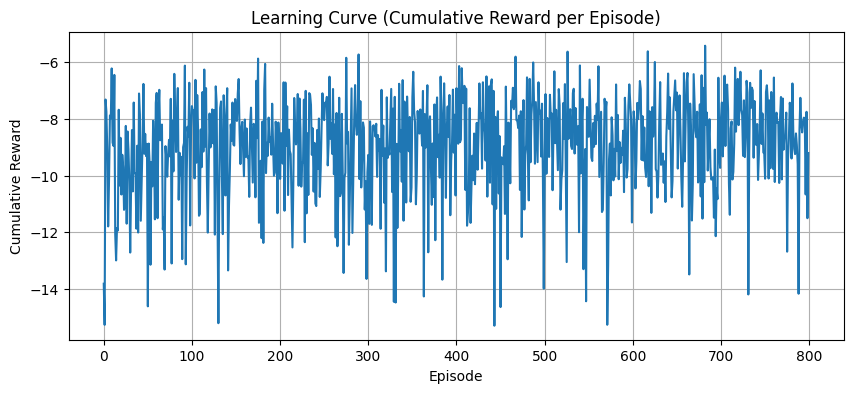

Saved results/gap_history.png


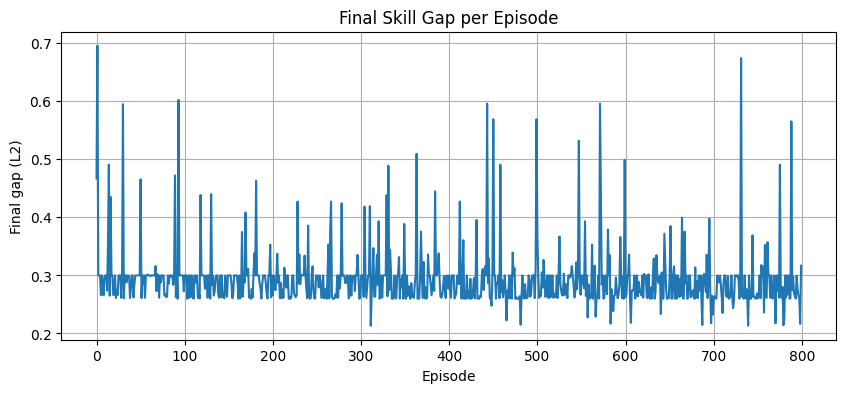

Saved training summary to results/training_summary.csv

Demonstration run using greedy policy from learned Q-table
Recommended course sequence (course indices): [9, 1, 1, 2, 4, 3, 5, 5, 5, 5]
Course names: ['Course_9', 'Course_1', 'Course_1', 'Course_2', 'Course_4', 'Course_3', 'Course_5', 'Course_5', 'Course_5', 'Course_5']

All done. Check the results/ folder for artifacts (plots and training_summary.csv).


In [ ]:
# Standard imports
import os
import json
import math
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: PyTorch for DQN (used only if available)
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False

# -----------------------------
# Configuration
# -----------------------------
CONFIG = {
    'data_dir': 'data',
    'results_dir': 'results',
    'learners_file': 'learners.csv',
    'courses_file': 'courses.csv',
    'job_skills_file': 'job_skills.csv',
    'num_episodes': 800,
    'max_steps_per_episode': 20,
    'discretize_bins': 10,  # for tabular Q-learning
    'alpha': 0.2,
    'gamma': 0.95,
    'epsilon_start': 0.3,
    'epsilon_end': 0.01,
    'epsilon_decay_episodes': 600,
    'save_every': 200,
}

os.makedirs(CONFIG['data_dir'], exist_ok=True)
os.makedirs(CONFIG['results_dir'], exist_ok=True)

# -----------------------------
# Utilities: safe file loading and synthetic generation
# -----------------------------

def try_load_csv(path):
    try:
        df = pd.read_csv(path)
        print(f"Loaded {path} (shape={df.shape})")
        return df
    except Exception as e:
        print(f"Could not load {path}: {e}")
        return None


def build_synthetic_data(num_skills=4, num_learners=50, num_courses=12):
    # Skills named skill0, skill1, ...
    learners = []
    for lid in range(num_learners):
        skills = np.round(np.random.uniform(0.1, 0.6, size=num_skills), 3)
        row = {'learner_id': lid}
        row.update({f'skill{i}': float(sk) for i, sk in enumerate(skills)})
        learners.append(row)
    learners_df = pd.DataFrame(learners)

    # Courses: each course affects 1-2 skills
    courses = []
    for cid in range(num_courses):
        affected = np.random.choice(num_skills, size=np.random.choice([1,2]), replace=False)
        improvements = np.round(np.random.uniform(0.08, 0.35, size=len(affected)), 3)
        courses.append({
            'course_id': cid,
            'course_name': f'Course_{cid}',
            'skill_index': ','.join(map(str, affected.tolist())),
            'improvement': ','.join(map(str, improvements.tolist())),
        })
    courses_df = pd.DataFrame(courses)

    # Job/target skill profile (single role)
    target = {f'skill{i}': 0.85 for i in range(num_skills)}
    job_skills_df = pd.DataFrame([{'role_name':'TargetRole', **target}])

    return learners_df, courses_df, job_skills_df

# -----------------------------
# Loader: auto-detect format and return structured objects
# -----------------------------

def load_or_create_data():
    learners_path = os.path.join(CONFIG['data_dir'], CONFIG['learners_file'])
    courses_path = os.path.join(CONFIG['data_dir'], CONFIG['courses_file'])
    job_skills_path = os.path.join(CONFIG['data_dir'], CONFIG['job_skills_file'])

    learners_df = try_load_csv(learners_path)
    courses_df = try_load_csv(courses_path)
    job_skills_df = try_load_csv(job_skills_path)

    if learners_df is None or courses_df is None or job_skills_df is None:
        print("Generating synthetic data because one or more data files are missing or failed to load.")
        learners_df, courses_df, job_skills_df = build_synthetic_data()

    # Detect skills columns in learners (everything except learner_id)
    learner_cols = [c for c in learners_df.columns if c != 'learner_id']
    skill_names = learner_cols
    num_skills = len(skill_names)

    # Parse courses into a list of (skill_indices_list, improvements_list)
    course_effects = []
    for _, row in courses_df.iterrows():
        si = row.get('skill_index', '')
        imp = row.get('improvement', '')
        # accept both single integers/floats and comma-separated strings
        if pd.isna(si) or str(si).strip() == '':
            raise ValueError('courses.csv must contain skill_index')
        si_list = [int(x.strip()) for x in str(si).split(',')]
        imp_list = [float(x.strip()) for x in str(imp).split(',')]
        if len(si_list) != len(imp_list):
            raise ValueError('skill_index and improvement lengths mismatch in courses.csv')
        course_effects.append((si_list, imp_list))

    # Job skills: pick first row as target (or allow selecting by role_name)
    # find skill columns in job_skills_df
    job_skill_cols = [c for c in job_skills_df.columns if c != 'role_name']
    if len(job_skill_cols) != num_skills:
        print('Warning: number of skill columns in job_skills does not match learners. If using your own data, ensure columns align. Falling back to synthetic target')
        target_skills = np.array([0.85]*num_skills)
    else:
        target_row = job_skills_df.iloc[0]
        target_skills = np.array([float(target_row[c]) for c in job_skill_cols])

    # Convert learners to numpy array of skill vectors
    learner_skill_vectors = learners_df[skill_names].values.astype(float)

    return skill_names, learner_skill_vectors, course_effects, target_skills, learners_df, courses_df, job_skills_df

# -----------------------------
# Environment: Gym-like
# -----------------------------
class SkillGapEnv:
    def __init__(self, initial_skills, target_skills, course_effects, max_steps=20, done_tol=0.05):
        # state and target should be numpy arrays (values 0-1)
        self.initial = np.array(initial_skills, dtype=float)
        self.state = self.initial.copy()
        self.target = np.array(target_skills, dtype=float)
        self.course_effects = course_effects
        self.max_steps = max_steps
        self.step_count = 0
        self.done_tol = done_tol
        self.action_space = len(course_effects)

    def reset(self, initial_skills=None):
        if initial_skills is not None:
            self.initial = np.array(initial_skills, dtype=float)
        self.state = self.initial.copy()
        self.step_count = 0
        return self.state.copy()

    def step(self, action):
        # Apply course effects
        si_list, imp_list = self.course_effects[action]
        for si, imp in zip(si_list, imp_list):
            self.state[si] = min(1.0, self.state[si] + imp)

        # reward: negative L2 gap (we want to maximize reward; smaller gap -> larger reward)
        gap = np.linalg.norm(self.target - self.state)
        reward = -gap

        self.step_count += 1
        done = (gap <= self.done_tol) or (self.step_count >= self.max_steps)
        info = {'gap': float(gap)}
        return self.state.copy(), float(reward), done, info

# -----------------------------
# Discretization helpers for tabular Q-learning
# -----------------------------

def discretize_state(state, bins):
    # state is vector of floats in [0,1]
    inds = np.floor(state * bins).astype(int)
    inds = np.clip(inds, 0, bins-1)
    # convert to tuple so it can be used as a dict key or index
    return tuple(inds.tolist())

# -----------------------------
# Q-Learning (tabular) implementation
# -----------------------------
class TabularQLearner:
    def __init__(self, action_space, state_bins, alpha=0.2, gamma=0.95, epsilon=0.2):
        self.action_space = action_space
        self.state_bins = state_bins
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.q = defaultdict(lambda: np.zeros(self.action_space))

    def choose(self, state_key):
        if random.random() < self.epsilon:
            return random.randrange(self.action_space)
        return int(np.argmax(self.q[state_key]))

    def update(self, state_key, action, reward, next_state_key):
        best_next = np.max(self.q[next_state_key])
        td = reward + self.gamma * best_next - self.q[state_key][action]
        self.q[state_key][action] += self.alpha * td

# -----------------------------
# Optional: simple DQN if torch available (small MLP)
# -----------------------------
if TORCH_AVAILABLE:
    class DQN(nn.Module):
        def __init__(self, n_inputs, n_actions, hidden=64):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_inputs, hidden),
                nn.ReLU(),
                nn.Linear(hidden, hidden),
                nn.ReLU(),
                nn.Linear(hidden, n_actions)
            )
        def forward(self, x):
            return self.net(x)

# -----------------------------
# Training loop wrapper
# -----------------------------

def train_q_learning(skill_names, learners, course_effects, target_skills, config=CONFIG):
    bins = config['discretize_bins']
    qlearner = TabularQLearner(action_space=len(course_effects), state_bins=bins,
                               alpha=config['alpha'], gamma=config['gamma'], epsilon=config['epsilon_start'])

    reward_history = []
    gap_history = []

    for ep in range(config['num_episodes']):
        # pick a random learner as starting state each episode
        start_idx = np.random.randint(0, learners.shape[0])
        env = SkillGapEnv(initial_skills=learners[start_idx], target_skills=target_skills,
                          course_effects=course_effects, max_steps=config['max_steps_per_episode'])
        state = env.reset()
        state_key = discretize_state(state, bins)

        total_reward = 0.0
        for step in range(config['max_steps_per_episode']):
            # epsilon schedule
            eps = max(config['epsilon_end'], config['epsilon_start'] - (config['epsilon_start']-config['epsilon_end']) * (ep / config['epsilon_decay_episodes']))
            qlearner.epsilon = eps

            action = qlearner.choose(state_key)
            next_state, reward, done, info = env.step(action)
            next_state_key = discretize_state(next_state, bins)

            qlearner.update(state_key, action, reward, next_state_key)

            state_key = next_state_key
            total_reward += reward
            if done:
                break

        reward_history.append(total_reward)
        gap_history.append(info['gap'])

        if (ep+1) % config['save_every'] == 0:
            # save q-table as json (convert keys to strings)
            qpath = os.path.join(config['results_dir'], f'q_table_ep{ep+1}.json')
            serializable_q = {str(k): v.tolist() for k, v in qlearner.q.items()}
            with open(qpath, 'w') as f:
                json.dump(serializable_q, f)
            print(f"Saved Q-table at episode {ep+1} to {qpath}")

    return qlearner, reward_history, gap_history

# -----------------------------
# Evaluation & plotting
# -----------------------------

def plot_results(reward_history, gap_history, results_dir=CONFIG['results_dir']):
    plt.figure(figsize=(10,4))
    plt.plot(reward_history)
    plt.xlabel('Episode')
    plt.ylabel('Cumulative Reward')
    plt.title('Learning Curve (Cumulative Reward per Episode)')
    plt.grid(True)
    p = os.path.join(results_dir, 'reward_history.png')
    plt.savefig(p)
    print(f'Saved {p}')
    plt.show()

    plt.figure(figsize=(10,4))
    plt.plot(gap_history)
    plt.xlabel('Episode')
    plt.ylabel('Final gap (L2)')
    plt.title('Final Skill Gap per Episode')
    plt.grid(True)
    p2 = os.path.join(results_dir, 'gap_history.png')
    plt.savefig(p2)
    print(f'Saved {p2}')
    plt.show()

# -----------------------------
# Example: run everything
# -----------------------------
if __name__ == '__main__':
    print('Loading data (will fallback to synthetic if needed)')
    skill_names, learners, course_effects, target_skills, learners_df, courses_df, job_skills_df = load_or_create_data()
    print(f'Number of skills detected: {len(skill_names)}')
    print('Sample learners shape:', learners.shape)
    print('Number of courses:', len(course_effects))

    # Train tabular Q-learning
    print('\nStarting Q-learning training...')
    qlearner, reward_hist, gap_hist = train_q_learning(skill_names, learners, course_effects, target_skills)

    # Save training plots and some artifacts
    plot_results(reward_hist, gap_hist)

    # Save a small summary CSV
    summary = pd.DataFrame({'episode': list(range(1, len(reward_hist)+1)), 'reward': reward_hist, 'final_gap': gap_hist})
    summary_path = os.path.join(CONFIG['results_dir'], 'training_summary.csv')
    summary.to_csv(summary_path, index=False)
    print(f'Saved training summary to {summary_path}')

    # Demonstration: run the learned policy on a sample learner and print recommended course sequence
    print('\nDemonstration run using greedy policy from learned Q-table')
    demo_start = 0
    env = SkillGapEnv(initial_skills=learners[demo_start], target_skills=target_skills, course_effects=course_effects, max_steps=10)
    state = env.reset()
    state_key = discretize_state(state, CONFIG['discretize_bins'])
    plan = []
    for step in range(10):
        # choose best action according to q table
        action = int(np.argmax(qlearner.q[state_key]))
        plan.append(action)
        next_state, reward, done, info = env.step(action)
        state_key = discretize_state(next_state, CONFIG['discretize_bins'])
        if done:
            break
    print('Recommended course sequence (course indices):', plan)
    # map to course names if available
    try:
        course_names = [c[0] if False else None for c in course_effects]  # placeholder to avoid lint issues
        # We have no direct course names here; courses_df exists though
        if 'courses_df' in globals() and not courses_df.empty:
            names = []
            for a in plan:
                # safeguard
                if a < len(courses_df):
                    names.append(str(courses_df.iloc[a].get('course_name', f'Course_{a}')))
                else:
                    names.append(f'Course_{a}')
            print('Course names:', names)
    except Exception:
        pass

    print('\nAll done. Check the results/ folder for artifacts (plots and training_summary.csv).')
